# **TP : Les vélos sur le pont de Fremont**

In [534]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement du fichier

In [535]:
local_file = "data/fremont.csv"
data = pd.read_csv(local_file)
data.shape #taille du tableau (lignes, colonnes)

(175200, 4)

In [536]:
data.head() #affiche les premières lignes du fichier

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


## Doublons

In [537]:
data.drop_duplicates(inplace=True) #supprime les doublons et enregistre le résultat dans le même tableau
data.shape #nouvelle taille sans doublons

(87600, 4)

## Échauffement : le ```DatetimeIndex```

In [538]:
sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])
print(f"Le type de sample_dates est {type(sample_dates)}\n")
print(f"sample_dates.date renvoie {sample_dates.date}, les dates du tableau.\n")
print(f"sample_dates.time renvoie {sample_dates.time}, les heures du tableau.\n")
print(f"sample_dates.dayofweek renvoie {sample_dates.dayofweek}, les jours de la semaine correspondants (0 pour lundi, 6 pour dimanche).\n")
print(f"Dates postérieures ou égales au 20 janvier 2024 : {sample_dates[sample_dates >= "2024-01-20"]}\n")
print(f"Dates de janvier 2024 : {sample_dates[(sample_dates.year == 2024) & (sample_dates.month == 1)]}")

Le type de sample_dates est <class 'pandas.DatetimeIndex'>

sample_dates.date renvoie [datetime.date(2024, 1, 15) datetime.date(2024, 1, 20)
 datetime.date(2024, 2, 3)], les dates du tableau.

sample_dates.time renvoie [datetime.time(8, 0) datetime.time(17, 30) datetime.time(12, 0)], les heures du tableau.

sample_dates.dayofweek renvoie Index([0, 5, 5], dtype='int32'), les jours de la semaine correspondants (0 pour lundi, 6 pour dimanche).

Dates postérieures ou égales au 20 janvier 2024 : DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)

Dates de janvier 2024 : DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)


## Parser les dates et renommer les colonnes

In [539]:
data.info() #informations sur le tableau

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          87600 non-null  str    
 1   Fremont Bridge Total          87586 non-null  float64
 2   Fremont Bridge East Sidewalk  87586 non-null  float64
 3   Fremont Bridge West Sidewalk  87586 non-null  float64
dtypes: float64(3), str(1)
memory usage: 4.5 MB


In [540]:
data.dtypes #types des données

Date                                str
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

In [541]:
data.index = pd.to_datetime(data.Date,format="%m/%d/%Y %I:%M:%S %p") #change l'index en un DatetimeIndex à partir de la colonne Date
data.drop(columns="Date",inplace=True) #supprime l'ancienne colonne Date
data.columns = ["Total","West","East"] #renomme les colonnes
data.head()

,Total,West,East
Date,,,
2022-08-01 00:00:00,23.0,7.0,16.0
2022-08-01 01:00:00,12.0,5.0,7.0
2022-08-01 02:00:00,3.0,0.0,3.0
2022-08-01 03:00:00,5.0,2.0,3.0
2022-08-01 04:00:00,10.0,2.0,8.0


## Données manquantes et extensions types

In [542]:
data[data["Total"].isna()] #affiche les lignes qui contiennent des valeurs manquantes

,Total,West,East
Date,,,
2013-03-10 02:00:00,NaN,NaN,NaN
2013-06-14 09:00:00,NaN,NaN,NaN
2013-06-14 10:00:00,NaN,NaN,NaN
2014-03-09 02:00:00,NaN,NaN,NaN
2015-03-08 02:00:00,NaN,NaN,NaN
2015-04-21 11:00:00,NaN,NaN,NaN
2015-04-21 12:00:00,NaN,NaN,NaN
2016-03-13 02:00:00,NaN,NaN,NaN
2017-03-12 02:00:00,NaN,NaN,NaN


In [543]:
data = data.convert_dtypes(convert_integer=True) #on convertit les données en entier
data.head()

,Total,West,East
Date,,,
2022-08-01 00:00:00,23,7,16
2022-08-01 01:00:00,12,5,7
2022-08-01 02:00:00,3,0,3
2022-08-01 03:00:00,5,2,3
2022-08-01 04:00:00,10,2,8


## ```resample()``` : changer la fréquence temporelle

<Axes: xlabel='Date'>

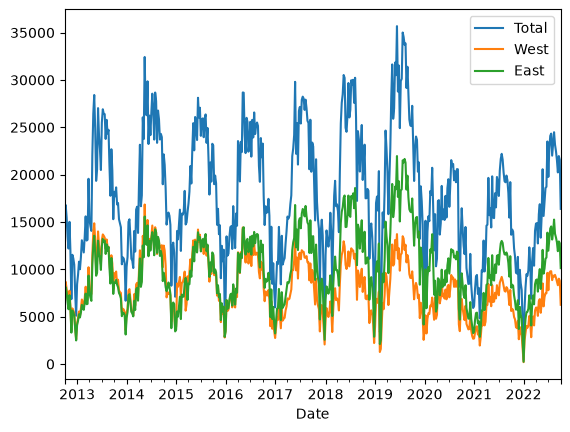

In [544]:
#Graphique qui représente la somme des passants par semaine
data.resample("1W").sum().plot()

In [545]:
print(data.shape)
print(data.resample("1W").sum().shape)

(87600, 3)
(522, 3)


Or 522 * 7 * 24 = 87697, ce qui est bien proche de 87600.

## Découpage temporel

In [546]:
data = data[data.index.year <= 2017] #On enlève les données après 2017
data.tail() #affiche les dernières lignes du tableau

,Total,West,East
Date,,,
2017-12-31 19:00:00,21,9,12
2017-12-31 20:00:00,14,6,8
2017-12-31 21:00:00,13,3,10
2017-12-31 22:00:00,13,7,6
2017-12-31 23:00:00,16,7,9


## Évolution annuelle

(0.0, 1059839.95)

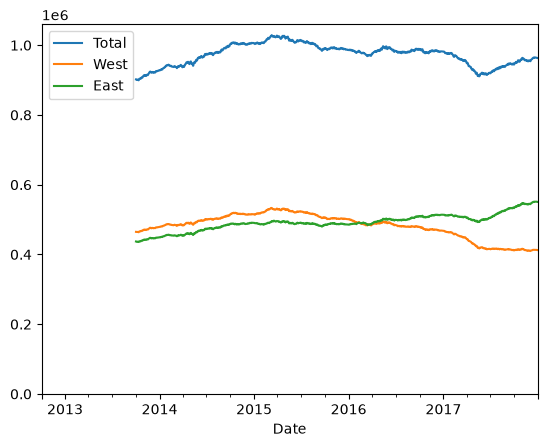

In [547]:
#Graphique qui représente la somme des passants sur les 365 derniers jours
graphique = data.resample("1D").sum().rolling(365).sum().plot()
graphique.set_ylim(0) #Fait commencer l'axe vertical à 0

## Profil journalier moyen

<Axes: xlabel='time'>

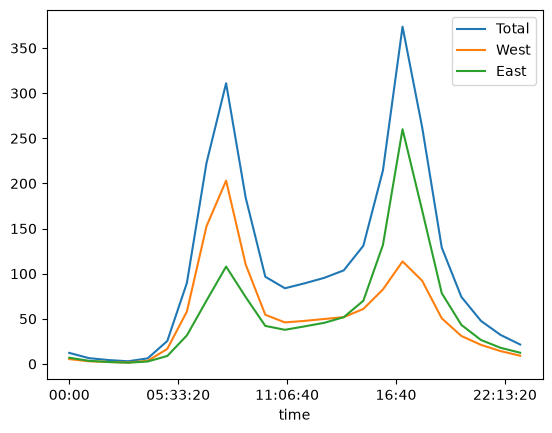

In [548]:
data.groupby(data.index.time).mean().plot() #On fait la moyenne du nombre de passants par heure

## Une courbe par jour : la ```pivot_table```

<Axes: xlabel='time'>

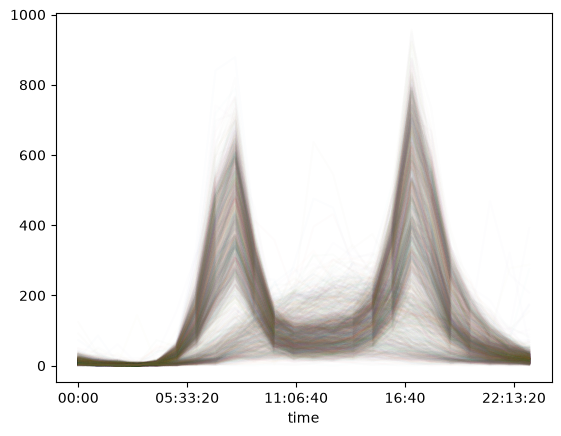

In [549]:
#Même type de graphique mais au lieu de faire une moyenne on affiche tous les jours
pivoted = data.pivot_table("Total",index=data.index.time,columns=data.index.date) #pivot table (colonnes = jours, lignes = heures)
pivoted.plot(legend=False,alpha=0.01)

## Classification des jours

### ACP

[[ 327.64078324   -6.76063235]
 [ 251.08260021   36.93578935]
 [ 149.3409454    43.17365982]
 ...
 [-551.91589387 -167.23062779]
 [-603.44893732  -46.56155526]
 [-616.9628518   -33.15205473]]


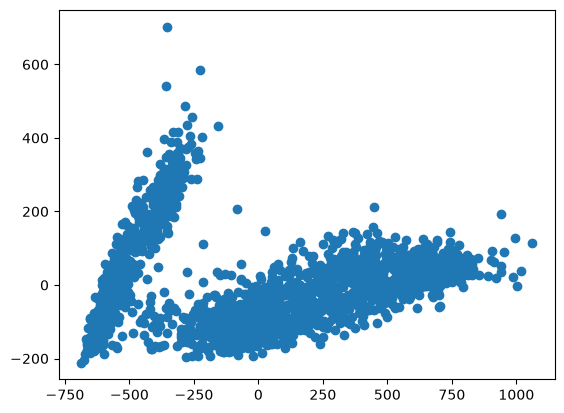

In [550]:
from sklearn.decomposition import PCA

pca_input = pivoted.T.fillna(0) #transposée de pivoted où les NaN sont remplacés par 0
pca = PCA(n_components=2).fit_transform(pca_input) #on réduit pca_input à 2 dimensions
print(pca)
plt.scatter(pca[:,0],pca[:,1])

### ```GaussianMixture```

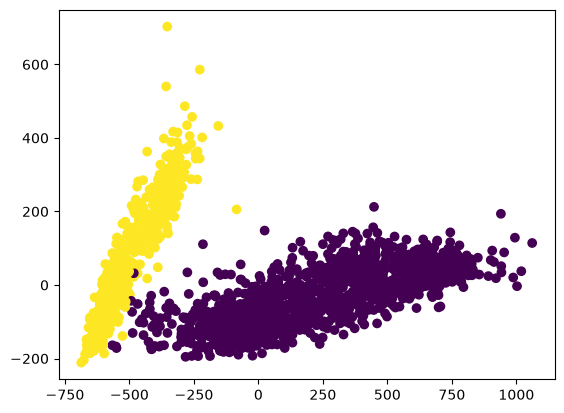

In [551]:
from sklearn.mixture import GaussianMixture

label = GaussianMixture(n_components=2).fit_predict(pca_input) #répartition en 2 groupes
plt.scatter(pca[:,0],pca[:,1],c=label)

### Comparons chaque famille aux profils journaliers

<Axes: xlabel='time'>

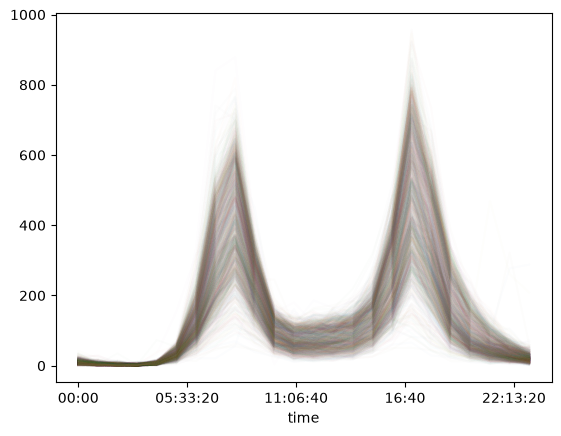

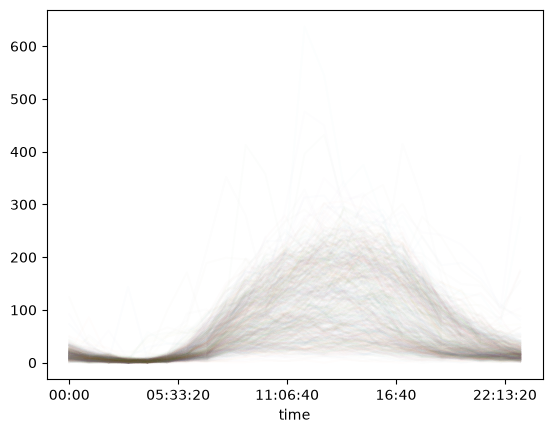

In [552]:
pivoted.loc[:,label==0].plot(legend=False, alpha=0.01)
pivoted.loc[:,label==1].plot(legend=False, alpha=0.01)

On voit que label a séparé les jours dont le profil suit la forme en U des autres jours.

### Vérifions avec le jour de la semaine

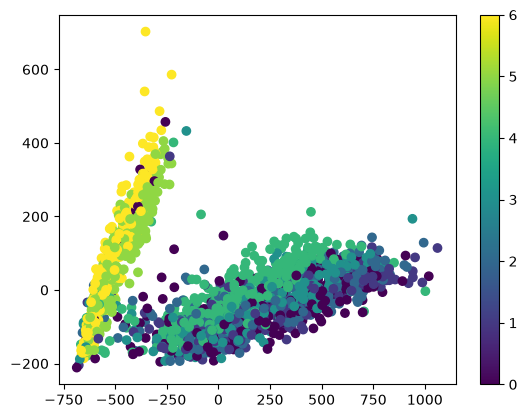

In [553]:
dates = pd.DatetimeIndex(pivoted.columns) #crée un DatetimeIndex à partir des colonnes de pivoted
jour = dates.dayofweek #renvoie les jours de la semaine correspondants
plt.scatter(pca[:,0],pca[:,1],c=jour)
plt.colorbar()

On observe que le "groupe du bas" correspond aux premiers jours de la semaine alors que le "groupe de gauche" correspond plutôt au week-end.

### Les moutons noirs

,2012-11-22,2012-11-23,2012-12-24,2012-12-25,2013-01-01,2013-05-27,2013-07-04,2013-07-05,2013-09-02,2013-11-28,...,2016-12-26,2017-01-02,2017-02-06,2017-05-29,2017-07-04,2017-09-04,2017-11-23,2017-11-24,2017-12-25,2017-12-26
00:00:00,8.0,15.0,6.0,2.0,7.0,15.0,23.0,124.0,38.0,12.0,...,4.0,1.0,4.0,12.0,10.0,28.0,3.0,9.0,2.0,2.0
01:00:00,39.0,0.0,2.0,2.0,21.0,12.0,14.0,35.0,18.0,6.0,...,1.0,1.0,1.0,3.0,11.0,6.0,4.0,2.0,0.0,0.0
02:00:00,4.0,2.0,1.0,1.0,16.0,4.0,61.0,12.0,7.0,4.0,...,4.0,1.0,0.0,1.0,1.0,8.0,8.0,4.0,0.0,0.0
03:00:00,4.0,0.0,1.0,2.0,6.0,2.0,6.0,3.0,4.0,2.0,...,0.0,1.0,0.0,1.0,3.0,3.0,4.0,0.0,0.0,0.0
04:00:00,1.0,3.0,4.0,1.0,4.0,2.0,4.0,8.0,7.0,4.0,...,4.0,1.0,2.0,3.0,8.0,5.0,1.0,5.0,0.0,8.0
05:00:00,4.0,9.0,11.0,1.0,3.0,12.0,17.0,17.0,5.0,3.0,...,5.0,4.0,4.0,15.0,12.0,14.0,2.0,9.0,1.0,12.0
06:00:00,4.0,11.0,16.0,3.0,7.0,17.0,32.0,74.0,15.0,5.0,...,10.0,11.0,9.0,29.0,31.0,30.0,7.0,23.0,0.0,12.0
07:00:00,10.0,22.0,37.0,4.0,3.0,42.0,59.0,189.0,55.0,22.0,...,24.0,17.0,22.0,40.0,64.0,49.0,11.0,29.0,2.0,24.0
08:00:00,23.0,25.0,29.0,4.0,11.0,65.0,108.0,199.0,69.0,20.0,...,11.0,29.0,43.0,83.0,99.0,93.0,23.0,52.0,1.0,41.0
09:00:00,44.0,15.0,42.0,7.0,14.0,57.0,137.0,196.0,116.0,45.0,...,27.0,32.0,29.0,120.0,198.0,153.0,25.0,56.0,1.0,38.0


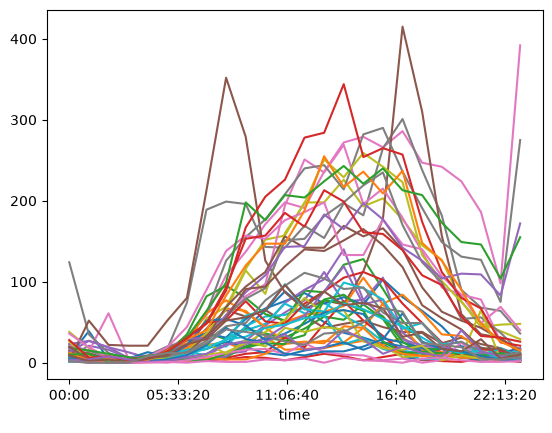

In [554]:
odd_index = (label==1) & (jour < 5) #condition pour qu'un jour de semaine appartienne au "groupe des jours de week-end"
pivoted.loc[:,odd_index].plot(legend=False) #affiche leur profil
odd_dates = dates[odd_index] #on récupère ces jours dans dates
pivoted[odd_dates] #puis dans pivoted

## Bonus : k-means, une troisième catégorie de jours ?

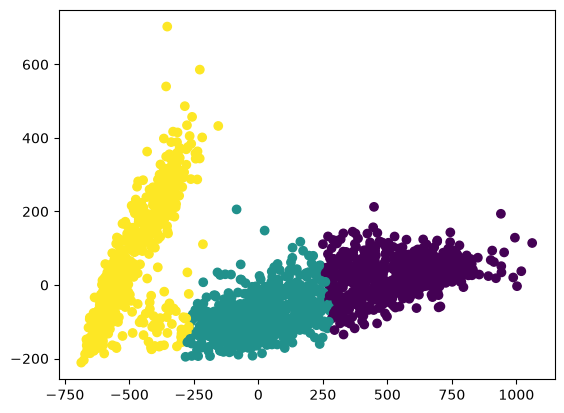

In [555]:
from sklearn.cluster import KMeans

#Cette fois on fait une répartition en 3 groupes

repartition = KMeans(n_clusters=3,n_init=10).fit_predict(pca_input)
plt.scatter(pca[:,0],pca[:,1],c=repartition)

In [556]:
day = pd.DatetimeIndex(pca_input.index).dayofweek
pd.crosstab(repartition,day)

col_0,0,1,2,3,4,5,6
row_0,,,,,,,
0,119,129,130,113,82,0,0
1,122,134,132,143,163,0,0
2,32,10,12,18,29,274,274


Le groupe 1 (ou 0 ou 2, ça change quand on refait "Run All") correspond au week-end (et des exceptions).

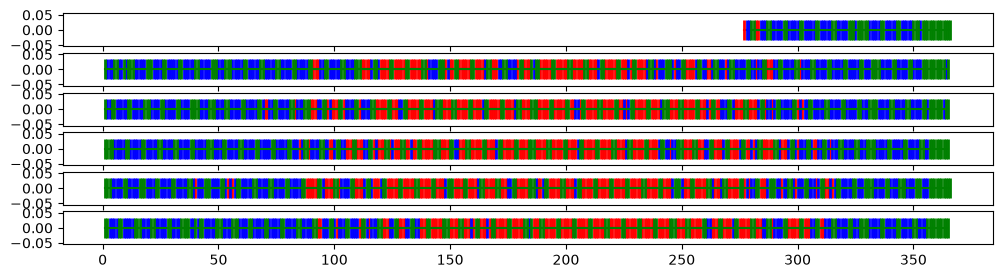

In [559]:
#Bande calendaire

fig, ax = plt.subplots(6,1,sharex=True,figsize=(12,3))
annees = dates.year
numerojour = dates.dayofyear
couleurs = ["Red","Blue","Green"]

for i in range(6):
    for j in range(3):
        liste = numerojour[(annees==2012+i) & (repartition==j)]
        ax[i].plot(liste,[0]*liste,linestyle=None,marker="|",markersize=15,markeredgewidth=2,color=couleurs[j])

#Il y avait sûrement plus simple mais je n'ai pas trouvé et ça a l'air de bien marcher comme ça

On observe que l'un des groupes correspond bien aux week-ends (et à la période de Noël aussi), et les 2 autres correspondent aux jours ouvrés, séparés en deux, autour des saisons estivale et hivernale.

<Axes: xlabel='time'>

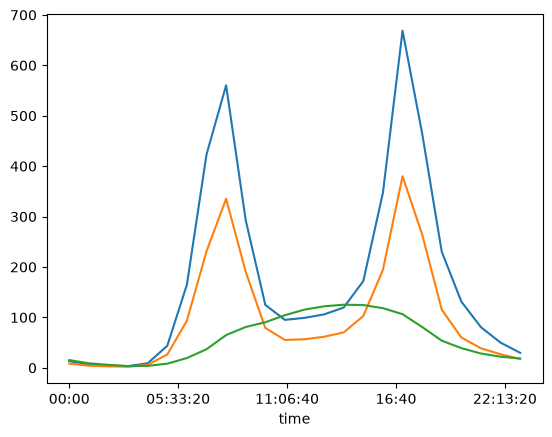

In [560]:
#Affichage des profils horaires moyens de chaque groupe
pca_input[repartition == 0].mean().plot()
pca_input[repartition == 1].mean().plot()
pca_input[repartition == 2].mean().plot()

On voit que deux groupes ont le même profil mais une amplitude différente : ils correspondent tous deux à des jours ouvrés, mais à des niveaux de trafic différents (en fonction des saisons).